In [1]:
import zipfile
import os

zip_path = "/content/archive (2).zip"
extract_path = "/content/google_play_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")
print("Files found:")

for file in os.listdir(extract_path):
    print(file)

ZIP extracted successfully!
Files found:
googleplaystore_user_reviews.csv
license.txt
googleplaystore.csv


In [2]:
import pandas as pd

apps = pd.read_csv("/content/google_play_data/googleplaystore.csv")
reviews = pd.read_csv("/content/google_play_data/googleplaystore_user_reviews.csv")

print("Apps dataset loaded:", apps.shape)
print("Reviews dataset loaded:", reviews.shape)

Apps dataset loaded: (10841, 13)
Reviews dataset loaded: (64295, 5)


In [3]:
print("========== APPS DATASET ==========")
display(apps.head())

print("\nApps columns:")
print(apps.columns.tolist())

print("\n========== REVIEWS DATASET ==========")
display(reviews.head())

print("\nReviews columns:")
print(reviews.columns.tolist())

========== APPS DATASET ==========


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



Apps columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

========== REVIEWS DATASET ==========


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000



Reviews columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [4]:
print("========== APPS DATASET ==========")

print("Missing values:")
print(apps.isnull().sum())

print("\nDuplicate rows:")
print(apps.duplicated().sum())


print("\n========== REVIEWS DATASET ==========")

print("Missing values:")
print(reviews.isnull().sum())

print("\nDuplicate rows:")
print(reviews.duplicated().sum())

========== APPS DATASET ==========
Missing values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Duplicate rows:
483

========== REVIEWS DATASET ==========
Missing values:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Duplicate rows:
33616


In [5]:
print("Duplicate app rows before cleaning:", apps.duplicated().sum())

apps = apps.drop_duplicates().copy()

print("Duplicate app rows after cleaning:", apps.duplicated().sum())
print("New Apps dataset shape:", apps.shape)

Duplicate app rows before cleaning: 483
Duplicate app rows after cleaning: 0
New Apps dataset shape: (10358, 13)


In [6]:
print("Duplicate review rows before cleaning:", reviews.duplicated().sum())

reviews = reviews.drop_duplicates().copy()

print("Duplicate review rows after cleaning:", reviews.duplicated().sum())
print("New Reviews dataset shape:", reviews.shape)

Duplicate review rows before cleaning: 33616
Duplicate review rows after cleaning: 0
New Reviews dataset shape: (30679, 5)


In [7]:
print("Missing review text:", reviews['Translated_Review'].isnull().sum())
print("Missing sentiment:", reviews['Sentiment'].isnull().sum())

print("\nUsable reviews:", reviews['Translated_Review'].notna().sum())
print("Reviews with sentiment:", reviews['Sentiment'].notna().sum())

Missing review text: 987
Missing sentiment: 982

Usable reviews: 29692
Reviews with sentiment: 29697


In [8]:
print("Rows before removing missing reviews:", len(reviews))

reviews = reviews.dropna(subset=['Translated_Review']).copy()

print("Rows after removing missing reviews:", len(reviews))
print("Missing review text after cleaning:", reviews['Translated_Review'].isnull().sum())

Rows before removing missing reviews: 30679
Rows after removing missing reviews: 29692
Missing review text after cleaning: 0


In [9]:
apps['Rating'] = pd.to_numeric(apps['Rating'], errors='coerce')

print("Rating data type:", apps['Rating'].dtype)
print("Missing ratings:", apps['Rating'].isna().sum())

print("\nRating range:")
print("Minimum:", apps['Rating'].min())
print("Maximum:", apps['Rating'].max())

Rating data type: float64
Missing ratings: 1465

Rating range:
Minimum: 1.0
Maximum: 19.0


In [11]:
import numpy as np

print("NumPy imported successfully!")

NumPy imported successfully!


In [12]:
# Replace invalid ratings outside the 1–5 range with missing values
apps.loc[(apps['Rating'] < 1) | (apps['Rating'] > 5), 'Rating'] = np.nan

print("Invalid ratings replaced with missing values.")

print("\nRating range after cleaning:")
print("Minimum:", apps['Rating'].min())
print("Maximum:", apps['Rating'].max())

print("\nMissing ratings after cleaning:", apps['Rating'].isna().sum())

Invalid ratings replaced with missing values.

Rating range after cleaning:
Minimum: 1.0
Maximum: 5.0

Missing ratings after cleaning: 1466


In [15]:
print("Unique values that cannot be converted to numbers:")

installs_test = (
    apps['Installs']
    .astype(str)
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)

invalid_installs = pd.to_numeric(installs_test, errors='coerce').isna()

print(apps.loc[invalid_installs, ['App', 'Category', 'Installs', 'Type', 'Price']])

Unique values that cannot be converted to numbers:
                                           App Category Installs Type  \
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9     Free    0   

          Price  
10472  Everyone  


In [16]:
print("Corrupted row before removal:")
display(apps.loc[10472])

# Remove the corrupted/misaligned row
apps = apps.drop(index=10472).copy()

print("\nCorrupted row removed successfully!")
print("New Apps dataset shape:", apps.shape)

Corrupted row before removal:


,10472
App,Life Made WI-Fi Touchscreen Photo Frame
Category,1.9
Rating,NaN
Reviews,3.0M
Size,"1,000+"
Installs,Free
Type,0
Price,Everyone
Content Rating,NaN
Genres,"February 11, 2018"



Corrupted row removed successfully!
New Apps dataset shape: (10357, 13)


In [17]:
apps['Installs'] = (
    apps['Installs']
    .astype(str)
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

print("Installs converted to numeric successfully!")
print("Data type:", apps['Installs'].dtype)
print("Minimum installs:", apps['Installs'].min())
print("Maximum installs:", apps['Installs'].max())

Installs converted to numeric successfully!
Data type: int64
Minimum installs: 0
Maximum installs: 1000000000


In [18]:
apps['Price'] = (
    apps['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .astype(float)
)

print("Price converted to numeric successfully!")
print("Data type:", apps['Price'].dtype)
print("Minimum price:", apps['Price'].min())
print("Maximum price:", apps['Price'].max())

Price converted to numeric successfully!
Data type: float64
Minimum price: 0.0
Maximum price: 400.0


In [19]:
def clean_size(value):
    if value == 'Varies with device':
        return np.nan

    if isinstance(value, str):
        if value.endswith('M'):
            return float(value[:-1])
        elif value.endswith('k'):
            return float(value[:-1]) / 1024

    return np.nan

apps['Size_MB'] = apps['Size'].apply(clean_size)

print("Size converted to MB successfully!")
print("Minimum size (MB):", apps['Size_MB'].min())
print("Maximum size (MB):", apps['Size_MB'].max())
print("Missing sizes:", apps['Size_MB'].isna().sum())


Size converted to MB successfully!
Minimum size (MB): 0.00830078125
Maximum size (MB): 100.0
Missing sizes: 1526


In [20]:
apps['Last Updated'] = pd.to_datetime(
    apps['Last Updated'],
    errors='coerce'
)

print("Last Updated converted successfully!")
print("Data type:", apps['Last Updated'].dtype)
print("Earliest date:", apps['Last Updated'].min())
print("Latest date:", apps['Last Updated'].max())
print("Missing dates:", apps['Last Updated'].isna().sum())

Last Updated converted successfully!
Data type: datetime64[ns]
Earliest date: 2010-05-21 00:00:00
Latest date: 2018-08-08 00:00:00
Missing dates: 0


In [21]:
apps['Reviews'] = pd.to_numeric(
    apps['Reviews'],
    errors='coerce'
)

print("Reviews converted to numeric successfully!")
print("Data type:", apps['Reviews'].dtype)
print("Minimum reviews:", apps['Reviews'].min())
print("Maximum reviews:", apps['Reviews'].max())
print("Missing reviews:", apps['Reviews'].isna().sum())

Reviews converted to numeric successfully!
Data type: int64
Minimum reviews: 0
Maximum reviews: 78158306
Missing reviews: 0


In [22]:
# Fill remaining missing categorical values
apps['Type'] = apps['Type'].fillna('Unknown')
apps['Content Rating'] = apps['Content Rating'].fillna('Unknown')
apps['Current Ver'] = apps['Current Ver'].fillna('Unknown')
apps['Android Ver'] = apps['Android Ver'].fillna('Unknown')

print("Missing values filled successfully!")
print("\nRemaining missing values:")
print(apps.isnull().sum()[apps.isnull().sum() > 0])

Missing values filled successfully!

Remaining missing values:
Rating     1465
Size_MB    1526
dtype: int64


In [24]:
import matplotlib.pyplot as plt

Number of apps in each category:
Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64


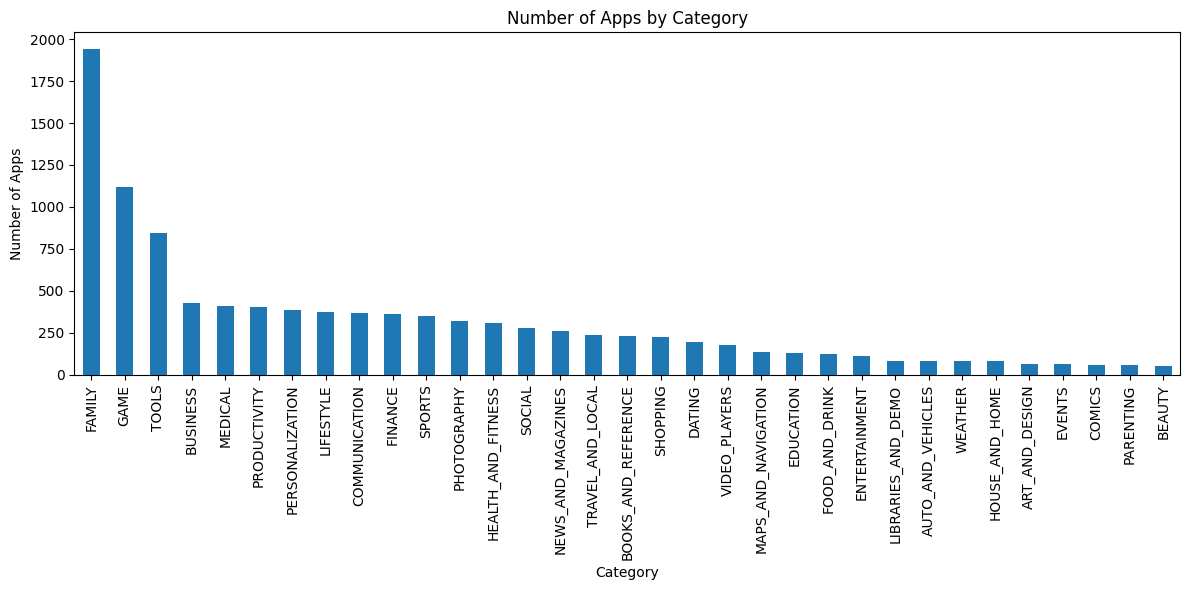

In [25]:
category_counts = apps['Category'].value_counts()

print("Number of apps in each category:")
print(category_counts)

# Visualization
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar')

plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Average Rating by Category:
Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
SHOPPING               4.251485
WEATHER                4.244000
SPORTS                 4.225175
PRODUCTIVITY           4.201796
FAMILY                 4.191153
AUTO_AND_VEHICLES      4.190411
PHOTOGRAPHY            4.182895
MEDICAL                4.182450
LIBRARIES_AND_DEMO     4.178462
HOUSE_AND_HOME         4.164706
FOOD_AND_DRINK         4.164151
COMICS                 4.155172
COMMUNICATION          4.151466
ENTERTAINMENT          4.136036
NEWS_AND_MAGAZINES     4.128505
FINANCE                4.127445
BUSINESS               4.102593
LIFESTYLE              4.096066
TRAVEL_AND_LOCAL       4.094146
VIDEO_PLAYERS          4.063750
MAP

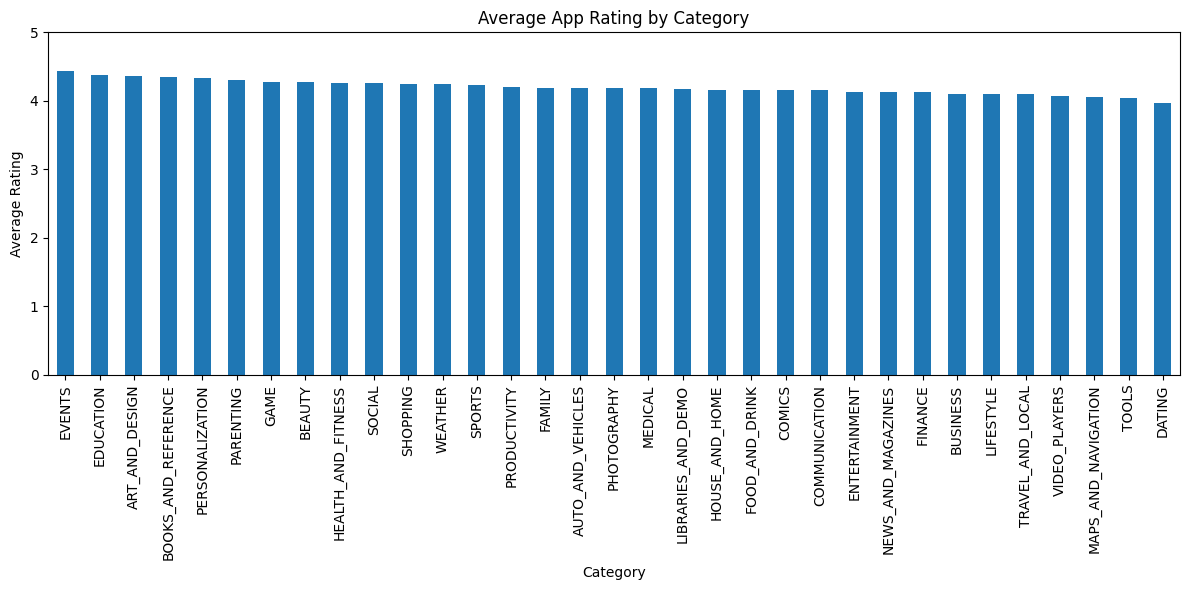

In [26]:
category_ratings = (
    apps.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Category:")
print(category_ratings)

plt.figure(figsize=(12, 6))
category_ratings.plot(kind='bar')

plt.title('Average App Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Total installs by category:
Category
GAME                   31544024415
COMMUNICATION          24152276251
SOCIAL                 12513867902
PRODUCTIVITY           12463091369
TOOLS                  11452771915
FAMILY                 10041692505
PHOTOGRAPHY             9721247655
TRAVEL_AND_LOCAL        6361887146
VIDEO_PLAYERS           6222002720
NEWS_AND_MAGAZINES      5393217760
SHOPPING                2573348785
ENTERTAINMENT           2455660000
PERSONALIZATION         2074494782
BOOKS_AND_REFERENCE     1916469576
SPORTS                  1528574498
HEALTH_AND_FITNESS      1361022512
BUSINESS                 863664865
FINANCE                  770348734
MAPS_AND_NAVIGATION      724281890
LIFESTYLE                534823539
EDUCATION                533952000
WEATHER                  426100520
FOOD_AND_DRINK           257898751
DATING                   206536107
HOUSE_AND_HOME           125212461
ART_AND_DESIGN           124338100
LIBRARIES_AND_DEMO        62995910
COMICS            

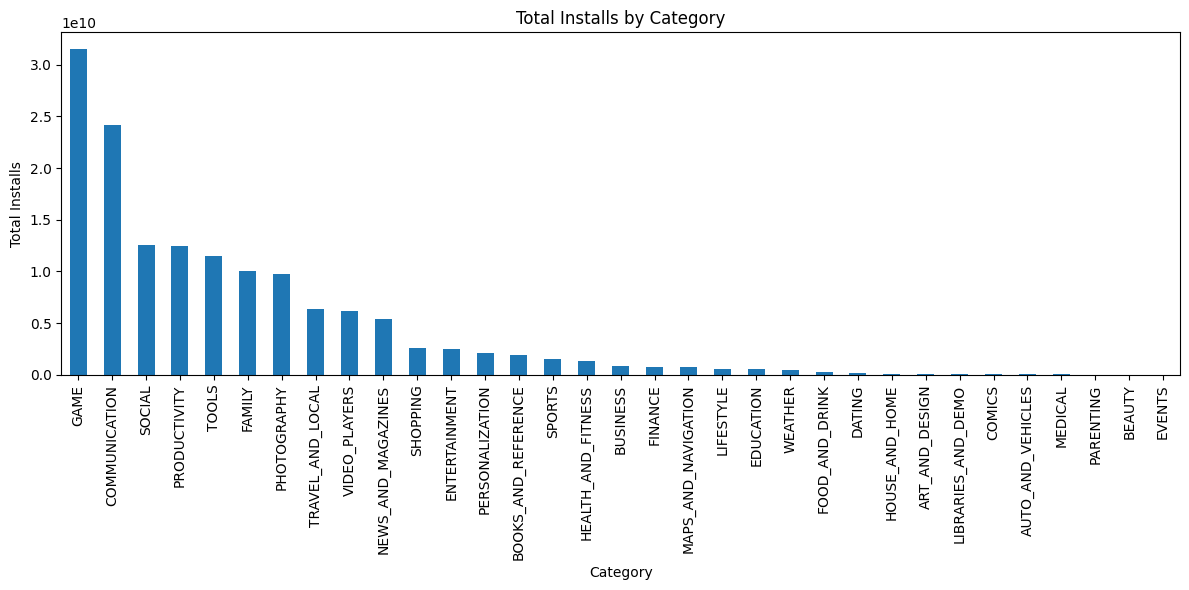

In [27]:
category_installs = (
    apps.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
)

print("Total installs by category:")
print(category_installs)

plt.figure(figsize=(12, 6))
category_installs.plot(kind='bar')

plt.title('Total Installs by Category')
plt.xlabel('Category')
plt.ylabel('Total Installs')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Free vs Paid Apps:
Type
Free       9591
Paid        765
Unknown       1
Name: count, dtype: int64


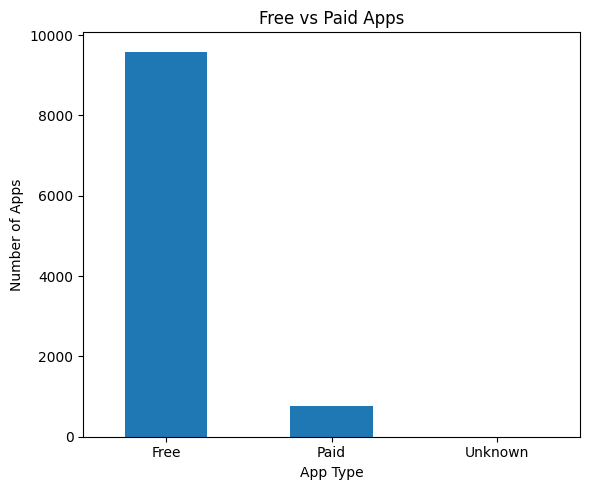

In [28]:
type_counts = apps['Type'].value_counts()

print("Free vs Paid Apps:")
print(type_counts)

plt.figure(figsize=(6, 5))
type_counts.plot(kind='bar')

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Number of paid apps: 765
Minimum price: 0.99
Maximum price: 400.0
Average price: 13.96


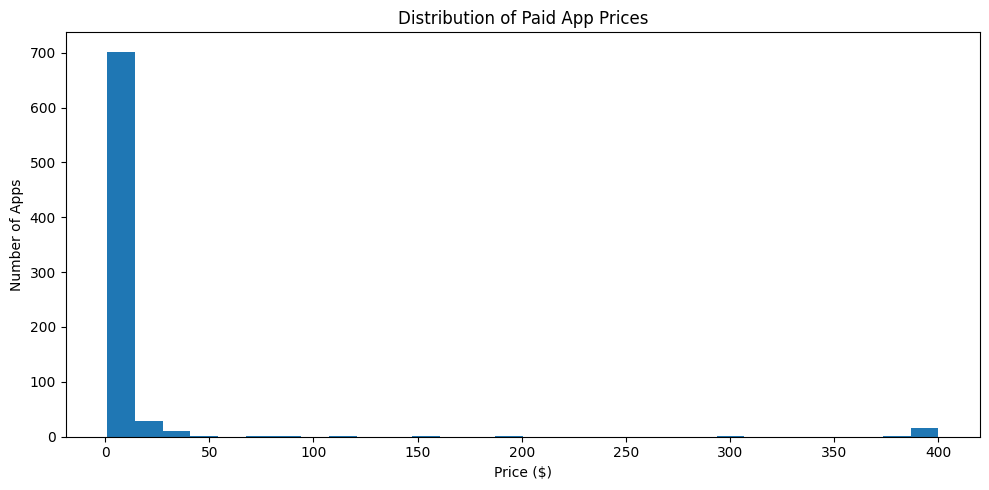

In [29]:
paid_apps = apps[apps['Type'] == 'Paid']

print("Number of paid apps:", len(paid_apps))
print("Minimum price:", paid_apps['Price'].min())
print("Maximum price:", paid_apps['Price'].max())
print("Average price:", round(paid_apps['Price'].mean(), 2))

plt.figure(figsize=(10, 5))
plt.hist(paid_apps['Price'], bins=30)

plt.title('Distribution of Paid App Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

Correlation between Rating and Reviews:
0.069


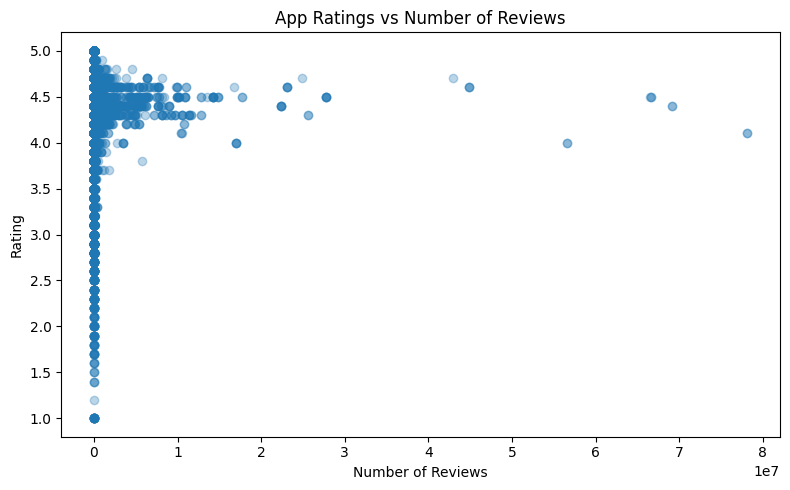

In [30]:
rating_reviews = apps[['Rating', 'Reviews']].dropna()

print("Correlation between Rating and Reviews:")
print(round(rating_reviews['Rating'].corr(rating_reviews['Reviews']), 3))

plt.figure(figsize=(8, 5))
plt.scatter(
    rating_reviews['Reviews'],
    rating_reviews['Rating'],
    alpha=0.3
)

plt.title('App Ratings vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

Correlation between App Size and Installs:
0.169


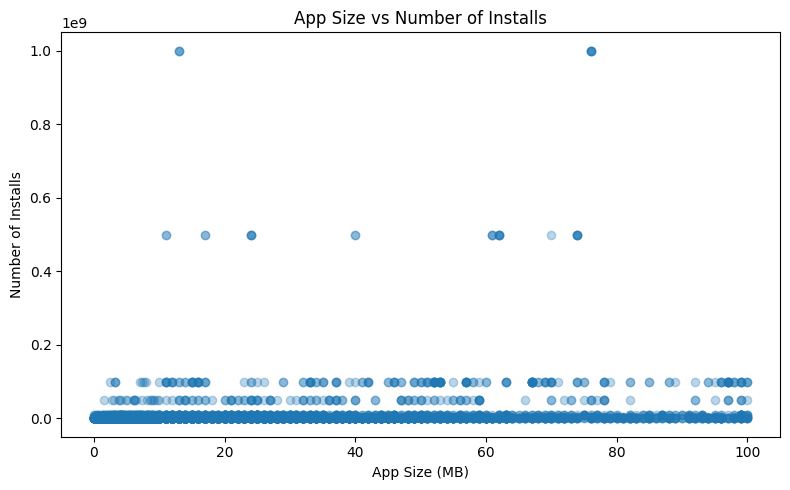

In [31]:
size_installs = apps[['Size_MB', 'Installs']].dropna()

print("Correlation between App Size and Installs:")
print(round(size_installs['Size_MB'].corr(size_installs['Installs']), 3))

plt.figure(figsize=(8, 5))
plt.scatter(
    size_installs['Size_MB'],
    size_installs['Installs'],
    alpha=0.3
)

plt.title('App Size vs Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')
plt.tight_layout()
plt.show()

In [32]:
from textblob import TextBlob

print("TextBlob imported successfully!")

TextBlob imported successfully!


In [33]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

reviews['TextBlob_Polarity'] = reviews['Translated_Review'].apply(get_polarity)

print("Sentiment polarity calculated successfully!")
print("Minimum polarity:", reviews['TextBlob_Polarity'].min())
print("Maximum polarity:", reviews['TextBlob_Polarity'].max())
print("Average polarity:", round(reviews['TextBlob_Polarity'].mean(), 3))

Sentiment polarity calculated successfully!
Minimum polarity: -1.0
Maximum polarity: 1.0
Average polarity: 0.189


Sentiment categories created successfully!

Sentiment distribution:
TextBlob_Sentiment
Positive    19014
Negative     6322
Neutral      4356
Name: count, dtype: int64


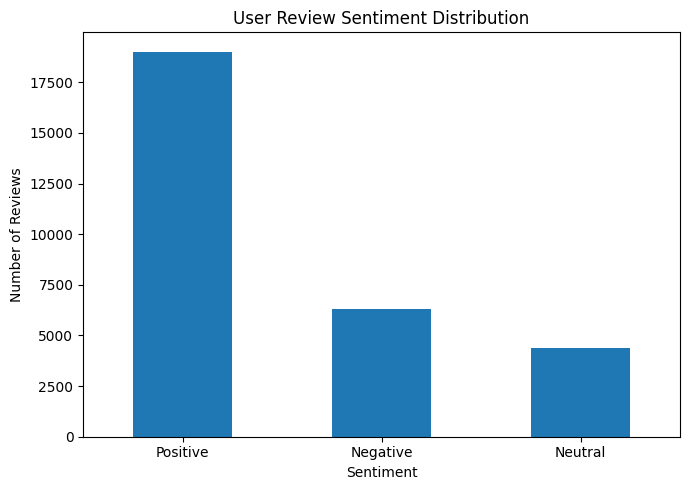

In [34]:
def get_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

reviews['TextBlob_Sentiment'] = reviews['TextBlob_Polarity'].apply(get_sentiment)

print("Sentiment categories created successfully!")
print("\nSentiment distribution:")
print(reviews['TextBlob_Sentiment'].value_counts())

plt.figure(figsize=(7, 5))
reviews['TextBlob_Sentiment'].value_counts().plot(kind='bar')

plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# Get the category for each app
app_category = apps[['App', 'Category']].drop_duplicates('App')

# Merge category information with reviews
reviews_with_category = reviews.merge(
    app_category,
    on='App',
    how='left'
)

print("Reviews with category information:")
print(reviews_with_category.shape)

# Calculate sentiment percentage by category
sentiment_by_category = pd.crosstab(
    reviews_with_category['Category'],
    reviews_with_category['TextBlob_Sentiment'],
    normalize='index'
) * 100

print("\nSentiment percentage by category:")
print(sentiment_by_category.round(2))

Reviews with category information:
(29692, 8)

Sentiment percentage by category:
TextBlob_Sentiment   Negative  Neutral  Positive
Category                                        
ART_AND_DESIGN          15.25    16.95     67.80
AUTO_AND_VEHICLES        6.01    12.72     81.27
BEAUTY                  18.93    25.55     55.52
BOOKS_AND_REFERENCE     13.61    17.18     69.21
BUSINESS                17.50    24.81     57.69
COMICS                   2.22    11.11     86.67
COMMUNICATION           20.70    18.48     60.82
DATING                  20.98    17.48     61.55
EDUCATION               11.65    12.58     75.78
ENTERTAINMENT           25.76    14.63     59.61
EVENTS                  10.26    10.90     78.85
FAMILY                  27.64    10.38     61.99
FINANCE                 22.46    14.60     62.95
FOOD_AND_DRINK          13.38    12.52     74.10
GAME                    35.47     5.43     59.09
HEALTH_AND_FITNESS      10.98    11.17     77.85
HOUSE_AND_HOME          17.75    21.5

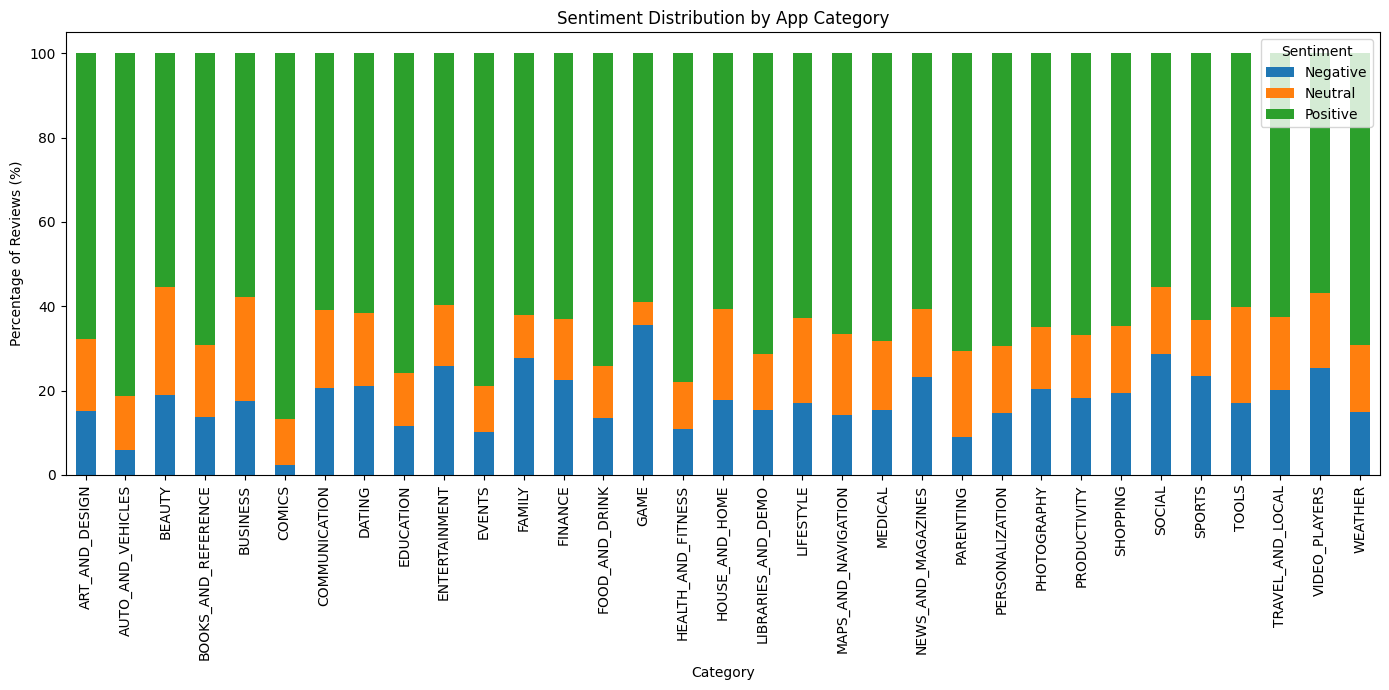

In [36]:
sentiment_by_category.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Sentiment Distribution by App Category')
plt.xlabel('Category')
plt.ylabel('Percentage of Reviews (%)')
plt.xticks(rotation=90)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [37]:
print("TOP 5 CATEGORIES BY NUMBER OF APPS")
print(category_counts.head(5))

print("\nTOP 5 CATEGORIES BY AVERAGE RATING")
print(category_ratings.head(5).round(2))

print("\nTOP 5 CATEGORIES BY TOTAL INSTALLS")
print(category_installs.head(5))

TOP 5 CATEGORIES BY NUMBER OF APPS
Category
FAMILY      1943
GAME        1121
TOOLS        843
BUSINESS     427
MEDICAL      408
Name: count, dtype: int64

TOP 5 CATEGORIES BY AVERAGE RATING
Category
EVENTS                 4.44
EDUCATION              4.38
ART_AND_DESIGN         4.36
BOOKS_AND_REFERENCE    4.35
PERSONALIZATION        4.33
Name: Rating, dtype: float64

TOP 5 CATEGORIES BY TOTAL INSTALLS
Category
GAME             31544024415
COMMUNICATION    24152276251
SOCIAL           12513867902
PRODUCTIVITY     12463091369
TOOLS            11452771915
Name: Installs, dtype: int64


## Key Data-Driven Insights

1. **Family dominates the app marketplace by volume:** The FAMILY category has the highest number of apps with 1,943 apps, followed by GAME (1,121) and TOOLS (843).

2. **Events has the highest average rating:** The EVENTS category has the highest average rating of 4.44, followed by EDUCATION (4.38) and ART_AND_DESIGN (4.36).

3. **Games have the highest user reach:** The GAME category has the highest total installs at approximately 31.54 billion, followed by COMMUNICATION (24.15 billion) and SOCIAL (12.51 billion).

## Conclusion

This analysis explored the Google Play Store app market using app information and user reviews. The data was cleaned by removing duplicate records, correcting invalid ratings, converting installs and prices into numeric values, converting app sizes into MB, and standardizing missing categorical values.

The analysis showed that FAMILY has the largest number of apps, while GAME has the highest total number of installs. EVENTS achieved the highest average rating among the categories analyzed. The sentiment analysis using TextBlob showed that user reviews were overall slightly positive, with an average sentiment polarity of 0.189.

These findings can help app developers and businesses understand category popularity, user engagement, pricing patterns, ratings, and customer sentiment when planning or improving applications.

In [38]:
apps.to_csv("/cleaned_googleplaystore.csv", index=False)
reviews.to_csv("/cleaned_googleplaystore_user_reviews.csv", index=False)

print("Cleaned datasets saved successfully!")
print("Apps:", apps.shape)
print("Reviews:", reviews.shape)

Cleaned datasets saved successfully!
Apps: (10357, 14)
Reviews: (29692, 7)
